
Processing Amazon | Distinct Rows: 1426337
  p=0.0050 | z=7131 | Seed=0
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
  p=0.0100 | z=14263 | Seed=100
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
  p=0.0150 | z=21395 | Seed=200
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-Credible: 80
    Credible: 0 | Non-C

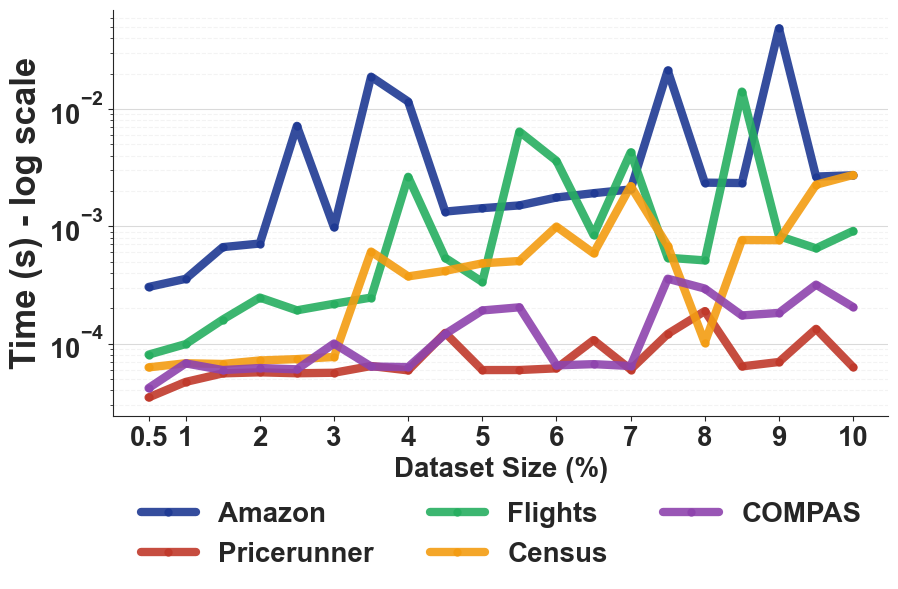

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

# ============================================================
# --- Range Detection (CD) Logic: EXACT PSEUDOCODE VERSION ---
# ============================================================

def precompute_S(z: int):
    """
    Computes all feasible witness intervals (b_minus, b_plus) for a given z.
    S(z) contains intervals that could potentially prove non-credibility.
    """
    deltas = np.arange(1, z, dtype=np.float64)

    # d(z, δ) denominator from Theorem 1
    d_denom = 3.0 * (z**2 - z + deltas * (2.0 * z + 1.0) - deltas**2)

    # g(z, δ) and s(z, δ) components
    g = (-deltas**3 + 3.0 * (deltas**2) * z + deltas * (z**2) + deltas + z**2 - z) / d_denom
    s = (z - deltas) * (z - deltas + 1.0) * (2.0 * deltas + z - 1.0) / d_denom

    b_minus = np.maximum(g - 1.0, s)
    b_plus = g

    # Filter for valid intervals where the range is non-empty
    valid = b_minus < b_plus
    return b_minus[valid], b_plus[valid]


def cd_filter_credible_mask(b_beta: np.ndarray, z: int, b_min: float, b_max: float):
    """
    Implements the core Range Detection filter.
    Returns a mask where True = Credible, False = Non-Credible.
    """
    b_minus, b_plus = precompute_S(z)
    credible = np.ones(len(b_beta), dtype=bool)

    # For each tuple in the returned set k
    for i, be in enumerate(b_beta):
        # Check against every witness interval in S(z)
        for low, high in zip(b_minus, b_plus):
            # Overlap test: If the potential range of 'be' intersects with a witness
            # it indicates evidence of systematic exclusion (non-credibility).
            if max(be - high, b_min) < min(be - low, b_max):
                credible[i] = False
                break # Early exit for this tuple once non-credibility is found

    num_credible = np.sum(credible)
    num_non_credible = len(credible) - num_credible
    print(f"    Credible: {num_credible} | Non-Credible: {num_non_credible}")
    return credible


def run_cd_benchmark(b_beta: np.ndarray, z: int, b_min: float, b_max: float):
    """Measures the execution time of the CD filter."""
    start_time = time.time()
    _ = cd_filter_credible_mask(b_beta, z, b_min, b_max)
    return time.time() - start_time


# ============================================================
# --- DATASET UTILITIES ---
# ============================================================

def load_dataset(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists(): raise FileNotFoundError(f"Path not found: {path}")
    return pd.read_csv(p)

def pick_numeric_column(df: pd.DataFrame, preferred: str | None) -> str:
    if preferred and preferred in df.columns: return preferred
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])][0]

def choose_returned_set(df_subset, k, mode, bias_col, returned_col, rng):
    """Selects k items from the subset to simulate query results."""
    n = len(df_subset)
    k_eff = min(k, n)
    if mode == "random":
        idx = rng.choice(n, size=k_eff, replace=False)
        return df_subset.iloc[idx][bias_col].to_numpy(dtype=float)
    # mode="topk" logic omitted for brevity as random is used here
    return df_subset.iloc[:k_eff][bias_col].to_numpy(dtype=float)


# ============================================================
# --- CONFIGURATION ---
# ============================================================

datasets = [
    {"name": "Amazon",      "path": "../data/real/amazon_products.csv"},
    {"name": "Pricerunner", "path": "../data/real/pricerunner_mobile.csv"},
    {"name": "Flights",     "path": "../data/real/flights.csv"},
    {"name": "Census",      "path": "../data/real/census.csv"},
    {"name": "COMPAS",      "path": "../data/real/compas.csv"},
]

# 20 points from 0.5% to 10%
percentages = np.linspace(0.005, 0.10, 20).tolist()
k_fixed =80
n_runs = 10
bias_col = None
returned_mode = "random"
returned_col = None

# Create a deterministic array of seeds for each percentage point
seeds_array = [i * 100 for i in range(len(percentages))]
colors = ["#1f3a93", "#c0392b", "#27ae60", "#f39c12", "#8e44ad"]
dataset_all_times = []

# ============================================================
# --- EXPERIMENT LOOP ---
# ============================================================

for idx, ds in enumerate(datasets):
    try:
        df_raw = load_dataset(ds["path"])
        # MANDATORY: Make whole dataset distinct by removing duplicate rows
        df_base = df_raw.drop_duplicates().reset_index(drop=True)
        z_full = len(df_base)
        print(f"\nProcessing {ds['name']} | Distinct Rows: {z_full}")
    except Exception as e:
        print(f"Skipping {ds['name']}: {e}")
        continue

    avg_times = []

    for i, p in enumerate(percentages):
        current_seed = seeds_array[i]
        rng = np.random.default_rng(current_seed)

        # 1. FIXED BIAS ASSIGNMENT: Random integers on whole dataset
        # This bias stays fixed for the specific run seed
        random_integers = rng.integers(low=0, high=z_full, size=z_full).astype(float)

        df = df_base.copy()
        bcol = pick_numeric_column(df, bias_col)
        df[bcol] = random_integers

        # 2. GLOBAL BOUNDS: Context derived from whole dataset range
        b_min_global = float(df[bcol].min())
        b_max_global = float(df[bcol].max())

        # 3. SUBSETTING: Take percentage p of the dataset
        z = max(2, int(z_full * p))
        df_shuffled = df.sample(frac=1, random_state=current_seed).reset_index(drop=True)
        df_subset = df_shuffled.iloc[:z]

        # 4. SELECT RETURNED SET k (from the subset)
        b_beta = choose_returned_set(df_subset, k_fixed, returned_mode, bcol, returned_col, rng)

        # 5. BENCHMARK
        print(f"  p={p:.4f} | z={z} | Seed={current_seed}")
        run_results = [run_cd_benchmark(b_beta, z, b_min_global, b_max_global) for _ in range(n_runs)]
        avg_times.append(float(np.mean(run_results)))

    dataset_all_times.append((ds["name"], avg_times, colors[idx % len(colors)]))

# ============================================================
# --- COMBINED PLOT (LOG SCALE - LEGEND AT BOTTOM) ---
# ============================================================

sns.set_style("ticks")
# Adjusted figure size for better bottom-legend spacing
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for name, ys, color in dataset_all_times:
    ys_safe = [y if y > 0 else 1e-6 for y in ys]
    ax.plot(percentages, ys_safe, marker="o", markersize=5, label=name,
            color=color, linewidth=6, alpha=0.9)

ax.set_yscale('log')
ax.set_xlabel("Dataset Size (%)", fontweight="bold", fontsize=20)
ax.set_ylabel("Time (s) - log scale", fontweight="bold", fontsize=25)

# X-tick formatting
tick_indices = np.linspace(0, len(percentages)-1, 11, dtype=int)
plt.xticks([percentages[i] for i in tick_indices],
           [f"{percentages[i]*100:g}" for i in tick_indices],
           fontweight='bold', fontsize=15)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(20)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(20)

ax.yaxis.grid(True, linestyle='-', which='major', color='#d1d1d1', alpha=0.8)
ax.yaxis.grid(True, linestyle='--', which='minor', color='#e1e1e1', alpha=0.4)

# --- NEW LEGEND LOGIC ---
# loc="upper center" combined with bbox_to_anchor places it outside the axis at the bottom
# ncol=3 organizes the labels into rows
leg = ax.legend(loc="upper center",
                bbox_to_anchor=(0.5, -0.15),
                ncol=3,
                frameon=False,
                fontsize=20,
                edgecolor='black')
plt.setp(leg.get_texts(), fontweight='bold')

sns.despine(trim=False)

# tight_layout doesn't always account for bbox_to_anchor legends,
# so we manually adjust the bottom margin.
plt.subplots_adjust(bottom=0.3)
plt.savefig("all_dataset_credible_tuples.png")